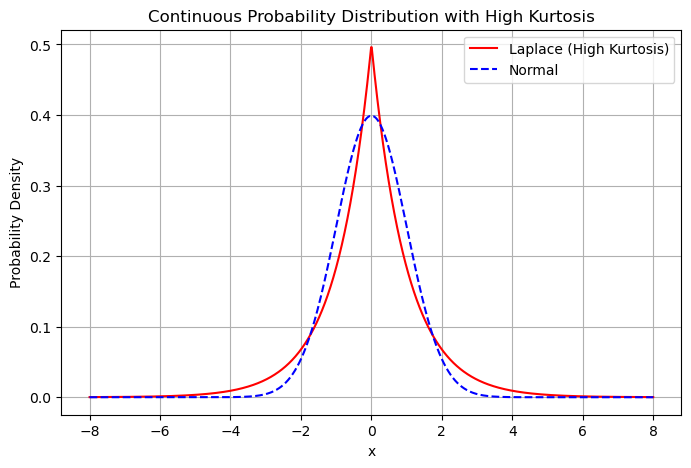

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import laplace, norm

# Create x-axis values
x = np.linspace(-8, 8, 1000)

# Laplace distribution (high kurtosis)
laplace_pdf = laplace.pdf(x, loc=0, scale=1)

# Normal distribution for comparison
normal_pdf = norm.pdf(x, loc=0, scale=1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, laplace_pdf, label='Laplace (High Kurtosis)', color='red')
plt.plot(x, normal_pdf, label='Normal', color='blue', linestyle='--')
plt.title('Continuous Probability Distribution with High Kurtosis')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True)
plt.show()


HIGH KURTOSIS MEANS THAT TAILS ARE HEAVY LEAVING MIDDLE NARROW AND SHARP. THERE'S HIGHER TENDANCE TO GET EXTREME VALUES THAN THOSE CLOSE TO THE MEAN.


State progression over 10 years:
Year 0: No Discount
Year 1: 25% Discount
Year 2: 50% Discount
Year 3: 50% Discount
Year 4: 50% Discount
Year 5: 50% Discount
Year 6: 50% Discount
Year 7: 25% Discount
Year 8: 50% Discount
Year 9: 50% Discount
Year 10: 50% Discount

Final state distribution after 10 years:
No Discount: 1 years
25% Discount: 2 years
50% Discount: 8 years


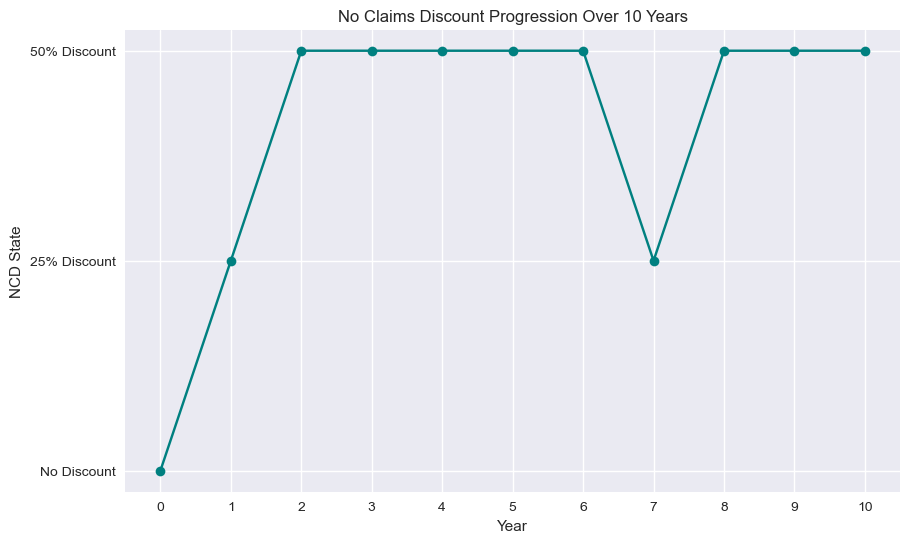

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Set random seed for reproducibility
random.seed(42)

# Define states
states = ["No Discount", "25% Discount", "50% Discount"]

# Transition probabilities
p_no_claim = 0.75  # probability of no claim in a year
p_claim = 0.25     # probability of making a claim

# Simulation parameters
years = 10
current_state = 0  # Start at State 1: No Discount
state_history = [current_state]

# Simulate transitions over 10 years
for _ in range(years):
    if random.random() < p_no_claim:
        # No claim: move up one state unless already at max
        current_state = min(current_state + 1, 2)
    else:
        # Claim: move down one state unless already at min
        current_state = max(current_state - 1, 0)
    state_history.append(current_state)

# Convert state history to labels
state_labels = [states[s] for s in state_history]

# Calculate final state distribution
final_distribution = {state: state_labels.count(state) for state in states}

# Print state progression and final distribution
print("State progression over 10 years:")
for year, state in enumerate(state_labels):
    print(f"Year {year}: {state}")

print("\nFinal state distribution after 10 years:")
for state, count in final_distribution.items():
    print(f"{state}: {count} years")

# Visualization
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(11), state_history, marker='o', linestyle='-', color='teal')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(states)
ax.set_xticks(range(11))
ax.set_xlabel("Year")
ax.set_ylabel("NCD State")
ax.set_title("No Claims Discount Progression Over 10 Years")
plt.grid(True)
plt.show()


**to better forecast, enlongate time period**

**AUTOCORRELATION ANALYSIS**

In [1]:
import statsmodels.graphics.tsaplots 

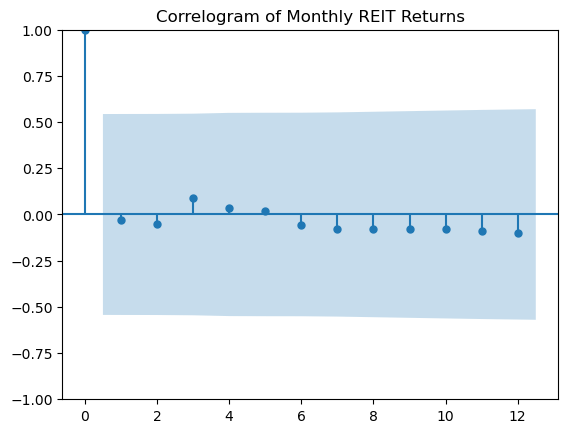

In [5]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Example: Monthly REIT returns
returns = [0.012, 0.013, 0.011, 0.014, 0.013, 0.012, 0.019,0.07,0.08,0.12,0.009,0.0089,0.76]  # Add full series

plot_acf(returns, lags=12)
plt.title("Correlogram of Monthly REIT Returns")
plt.show()


In [6]:
from statsmodels.tsa.stattools import adfuller

# Monthly REIT returns
returns = [0.01, 0.015, 0.013, 0.014, 0.013, 0.011, 0.019, 0.012, 0.009, 0.008, 0.009, 0.76]

result = adfuller(returns)
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -12.467698813800935
p-value: 3.297400930506768e-23


In [ ]:
.